# Notebook for Processing TR-XRD Data using the TRXRD Code

**Edit the settings cell below before running this notebook.**

## Import Necessary Packages

In [2]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.ndimage import gaussian_filter1d
import tifffile as tf

import trxrd

%matplotlib widget

## Define Experimental Parameters

In [ ]:
# Experimental Parameters and Defaults
# ============================================================
# Data and Mask Paths, Scan Name, and Filename Pattern
# ============================================================
DATA_PATH = Path(r"\\s7data\beams46\7IDC\Cotts\2025_11Exp\18keV\BTO400S3_18keV") # Path to directory containing TIFF files
MASK_FILE = Path(r"C:\Users\lheald\Documents\Guzelturk_Lab\TRXRDPython\testdata\mask_2021_dec.tif") # Path to mask file
SCAN_NAME = "BTO400nmS3_360Klong" # Prefix in file name to identify relevant files, e.g. "550nm_re" etc.
SCAN_TYPE = "delay_scan" # Type of scan based on filename pattern, e.g. "delay_scan", "theta_samz", etc. Must correspond to a key in the "filename_patterns" dictionary in trxrd.py
BACKGROUND_PATH = Path(r"\\s7data\beams46\7IDC\Cotts\2025_11Exp\18keV\BlankSubstrate\BlankSubstrate_1p0theta-1.0fshw2e-08delay00007_9578.tif")
SAVE_PATH = Path(r"C:\Users\lheald\Documents\Guzelturk_Lab\Cotts_Processed_Data\BTO_18keV\BTO400nmS3_360Klong") # Path to directory where processed data will be saved, e.g. as .h5 file
# PONI file from pyFAI-calib2. Set to a Path to use PONI geometry;
# set to None to use the manual parameters below.
PONI_FILE = Path(r"C:\Users\lheald\Documents\Guzelturk_Lab\Cotts_Processed_Data\CeO2_18keV\CeO2_18keV.poni") # Path to .poni file, or None
# ============================================================
# General Defaults
# ============================================================
FIGSIZE = (10, 4)
STD_FACTOR = 3
MAX_PROCESSORS = 4
DELAY_SIGN = -1 # Check file naming scheme, sometimes positives delays have "-" in front and negative have no sign so need to invert sign

# ============================================================
# Beam Stop Mask Defaults
# ============================================================
MASK_CENTER_X = 52
MASK_CENTER_Y = 1667
MASK_RADIUS = 30

# ============================================================
# Center Guess and Sampling Defaults
# ============================================================
CENTER_X = 44
CENTER_Y = 1666
DOWNSAMPLE = 2 # Downsample factor for center finding, e.g. 2 means use every other pixel, 4 means use every 4th pixel, etc.

# ============================================================
# Detector Parameters and Defaults
# ============================================================

# Detector and beam parameters
PIXEL1 = 1.72e-4                 # m, detector pixel size along rows (y)
PIXEL2 = 1.72e-4                 # m, detector pixel size along cols (x)
DISTANCE = 0.1723                 # m, sample-to-detector distance
WAVELENGTH = 0.39738514824147314e-10          # m

# Detector orientation
TILT_ANGLE = np.deg2rad(0)               # rad
TILT_PLANE_ROTATION = np.deg2rad(90)      # rad
ROT3 = 0.0                      # rad, in-plane detector rotation

# Optional corrections
POLARIZATION_FACTOR = 0.999      # e.g. 0.99 or None
DARK = None                     # 2D dark image or None
FLAT = None                     # 2D flat-field image or None

# ============================================================
# Azimuthal Averaging and Normalization Defaults
# ============================================================
UNIT = "q_A^-1" # Unit for x-axis of azimuthally averaged data, e.g. "q_A^-1" for inverse Angstroms, "2theta_deg" for degrees, etc. 
NAN_MIN = 0.35 # Minimum value for valid data, values below this will be set to NaN, e.g. 0.35 or None for no minimum threshold
NAN_MAX = None # Maximum value for valid data, values above this will be set to NaN, e.g. 1.0 or None for no maximum threshold
NORM_MIN = 4.05 # Minimum value for normalization, values below this will be set to this value before normalization, e.g. 0.5 or None for no minimum threshold
NORM_MAX = 4.25 # Maximum value for normalization, values above this will be set to this value before normalization, e.g. 1.0 or None for no maximum threshold
N_POINTS = 3000 # Number of points for azimuthal averaging, e.g. 3000 or None to use all pixels

# ============================================================
# Background Subtraction Defaults
# ============================================================
BACKGROUND_NORM_MIN = 1.0 # Minimum value for background normalization, values below this will be set to this value before normalization, e.g. 0.5 or None for no minimum threshold
BACKGROUND_NORM_MAX = 1.5 # Maximum value for background normalization, values above this will be set to this value before normalization, e.g. 1.0 or None for no maximum threshold

# ============================================================
# Baseline Subtraction Defaults
# ============================================================
LAM_VAL = 1e4
P_VAL = 0.05

# ============================================================
# PDF Calcuation Defaults
# ============================================================
COMPOSITION = "BaTiO3" # Sample composition for form factor calculation, e.g. "BaTiO3" or None for no form factor correction
R_MAX = 20.0 # Maximum r value for PDF calculation, e.g. 20.0 or None for no maximum
N_R = 2000 # Number of r points for PDF calculation, e.g.
Q_MIN = 0.5 # Minimum q value for PDF calculation, e.g. 0.5 or None for no minimum
Q_MAX = 15.0 # Maximum q value for PDF calculation, e.g. 16.0 or None for no maximum
WINDOW = "lorch" # Window function for PDF calculation, e.g. "lorch", "hanning", "blackman", or None for no window
# ============================================================
# Optional Saving .dat Files
# ============================================================
SAVE_AZAV_DAT = True # Whether to save azimuthally averaged profiles as .dat files in addition to the .h5 file, e.g. True or False
# ============================================================
# Form Factor CSV File
# ============================================================
FORM_FACTOR_FILE = Path(
    r"C:\Users\lheald\Documents\Guzelturk_Lab\gued\packages\x_ray_ff\atomic_FF_coeffs_clean.csv"
)

## Define File Paths

In [4]:
# Main diffraction data folder
data_path = DATA_PATH

# Check number of files in folder 
file_names = sorted(data_path.glob(f"{SCAN_NAME}-*.tif"))
print(f"{len(file_names)} TIFF files found in {data_path}.")

# Detector mask file
mask_file = MASK_FILE
print(f"Using mask file: {mask_file}")

sample_files = sorted(DATA_PATH.glob(f"{SCAN_NAME}-*.tif"))
sample_image = tf.imread(str(sample_files[0]))

557 TIFF files found in \\s7data\beams46\7IDC\Cotts\2025_11Exp\18keV\BTO400S3_18keV.
Using mask file: C:\Users\lheald\Documents\Guzelturk_Lab\TRXRDPython\testdata\mask_2021_dec.tif


## Build Combined Masks

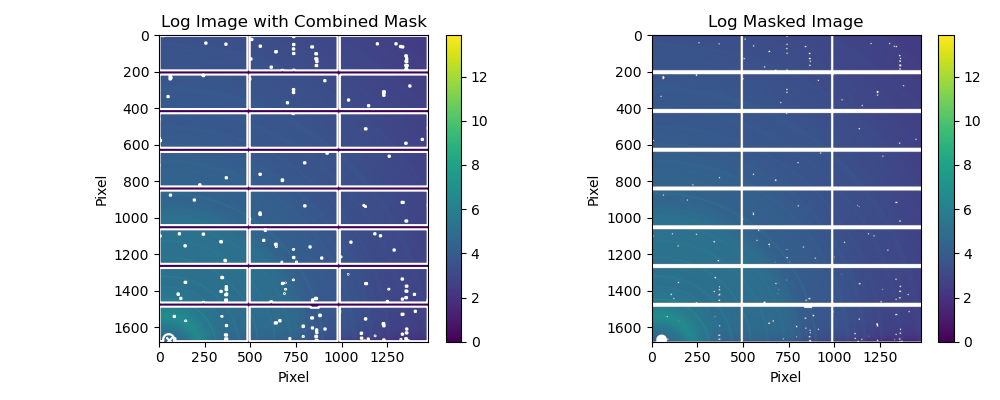

In [5]:
combined_mask = trxrd.build_combined_mask(
    sample_image.shape,
    center_xy = (MASK_CENTER_X, MASK_CENTER_Y),
    radius = MASK_RADIUS,
    detector_mask=None,
    mask_path=MASK_FILE,
    plot=True,
    example_image=sample_image,
)

## Import Images and Azimuthal Average

This can take a few minutes if you're loading in hundreds of images. Might crash with thousands of images...

557 TIFF files found in \\s7data\beams46\7IDC\Cotts\2025_11Exp\18keV\BTO400S3_18keV with scan name BTO400nmS3_360Klong.
Integrating 557 images (streaming)...
  Completed 100/557 (18.0%)
  Completed 200/557 (35.9%)
  Completed 300/557 (53.9%)
  Completed 400/557 (71.8%)
  Completed 500/557 (89.8%)
  Completed 557/557 (100.0%)
Done integrating.


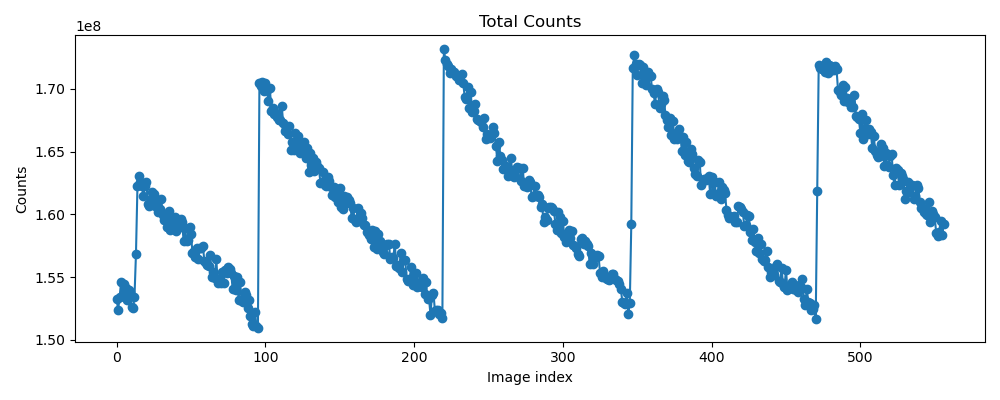

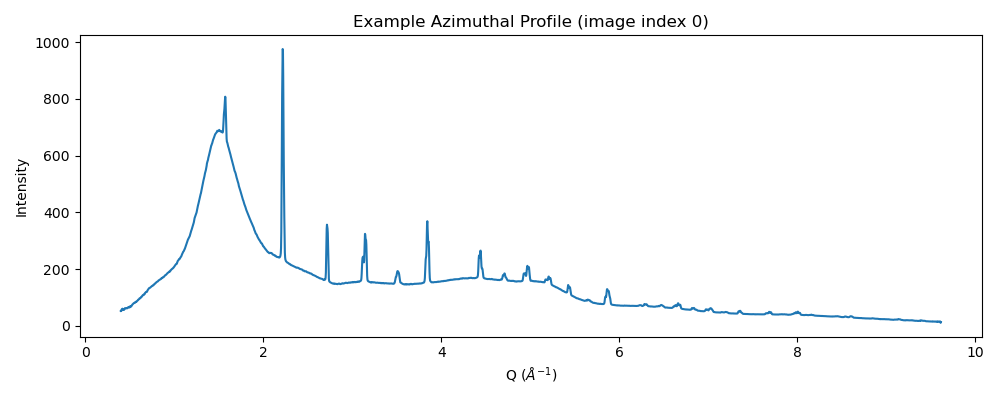

q shape: (3000,)
profiles shape: (557, 3000)
Unique delays: [-8.000e-08 -1.000e-08 -5.000e-09  2.000e-10  4.000e-10  6.000e-10
  8.000e-10  1.000e-09  2.000e-09  3.500e-09  5.000e-09  1.000e-08
  2.000e-08  3.000e-08  4.000e-08  5.000e-08  6.000e-08  8.000e-08
  1.000e-07  1.500e-07  2.500e-07  3.750e-07  5.000e-07  7.500e-07
  1.000e-06  1.626e-06  2.688e-06  3.750e-06  5.000e-06  7.500e-06
  1.000e-05  1.350e-05]


In [6]:
az_result = trxrd.get_azimuthal_average_for_image(
    folder_path=DATA_PATH,
    sample_name=SCAN_NAME,
    filename_scheme=SCAN_TYPE,
    sort_key="image_number",
    delay_sign=DELAY_SIGN,
    poni_path=PONI_FILE,          # handles geometry; set to None and pass centers_xy if using manual geometry
    npt=N_POINTS,
    unit=UNIT,
    nan_radial_range=(NAN_MIN, NAN_MAX),
    integration_mask=combined_mask,
    max_workers=MAX_PROCESSORS,
    progress_interval=100,
    plot=True,                    # plots counts vs image index
)

q         = az_result["radial"]
profiles  = az_result["profiles"]
delays    = az_result["delay"]
counts    = az_result["counts"]
fluences  = az_result["fluence"]

print("q shape:", q.shape)
print("profiles shape:", profiles.shape)
print("Unique delays:", np.unique(delays))


## Normalize Azimuthal Averages

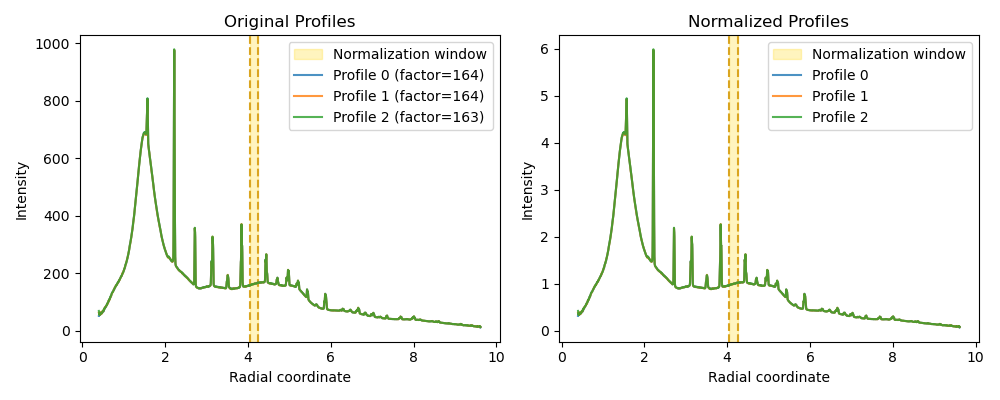

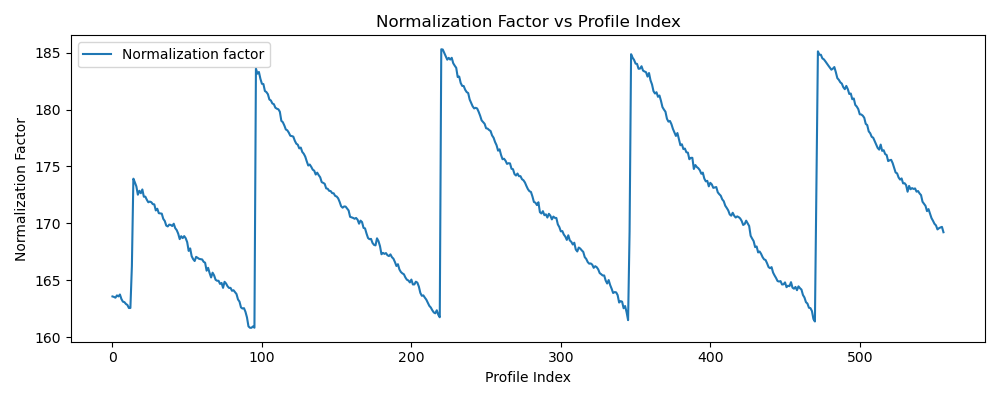

In [7]:
norm_result = trxrd.normalize_profiles_to_range(
    radial=q,
    profiles=profiles,
    norm_range=(NORM_MIN, NORM_MAX),   # example
    mode="mean",
    plot=True,
    plot_indices=[0, 1, 2],
    show_normalized_plot=True,
    return_dict=True,
    plot_factors=True,
)

profiles_norm = norm_result["normalized_profiles"]

## Load and Prepare Background Image(s)

**Make sure you're treating the background and the data the same! i.e., same masks, same centers, etc**

Loading background from: \\s7data\beams46\7IDC\Cotts\2025_11Exp\18keV\BlankSubstrate\BlankSubstrate_1p0theta-1.0fshw2e-08delay00007_9578.tif
dict_keys(['files', 'background_stack', 'background_mean', 'background_std', 'n_images'])
Background stack shape: (1, 1679, 1475)
Background mean shape: (1679, 1475)


C:\Users\lheald\AppData\Local\Temp\ipykernel_26240\2325887684.py:22: RuntimeWarning: Mean of empty slice
  bg_dict["background_mean"] = np.nanmean(bg_dict["background_stack"], axis=0)


Using PONI geometry from file: C:\Users\lheald\Documents\Guzelturk_Lab\Cotts_Processed_Data\CeO2_18keV\CeO2_18keV.poni for background azimuthal average.
Integrating 1 images...
  Completed 1/1 (100.0%)
Done integrating.


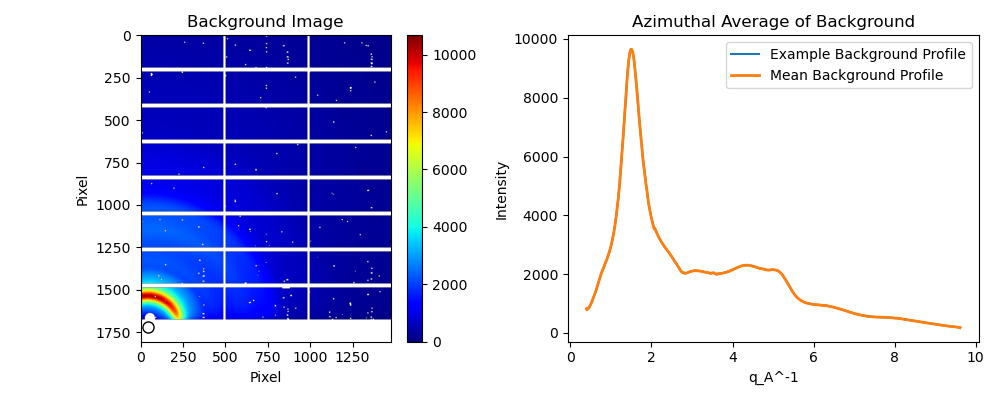

In [8]:
# Background path can be either:
# - a single tif file
# - or a folder containing many background tif files
# Load Data
print(f"Loading background from: {BACKGROUND_PATH}")
bg_dict = trxrd.load_background(
    background_path=BACKGROUND_PATH,
    sort=True,
    plot=False,
)

print(bg_dict.keys())
print("Background stack shape:", bg_dict["background_stack"].shape)
print("Background mean shape:", bg_dict["background_mean"].shape)

bg_dict["background_stack"] = trxrd.apply_mask_from_bool(
    data_array=bg_dict["background_stack"],
    mask_bool=combined_mask,
)


bg_dict["background_mean"] = np.nanmean(bg_dict["background_stack"], axis=0)


# Compute background azimuthal average
if PONI_FILE is not None:
    print(f"Using PONI geometry from file: {PONI_FILE} for background azimuthal average.")
    bg_az_result = trxrd.compute_background_azimuthal_average(
        background_input=bg_dict["background_stack"],
        centers_xy=None,   # one average center in (x, y)
        poni_path=PONI_FILE,
        npt=N_POINTS,
        unit=UNIT,
        nan_radial_range=(NAN_MIN, NAN_MAX),   # set Q < 0.3 to NaN
        azimuth_range=None,
        integration_mask=combined_mask,
        return_dict=True,
        progress_interval=100,
        use_custom_polarization=False,
        integration_function="integrate1d",
        correct_solid_angle=False,
        plot=True,
    )
else:
    bg_az_result = trxrd.compute_background_azimuthal_average(
        background_input=bg_dict["background_stack"],
        centers_xy=(CENTER_X, CENTER_Y),   # one average center in (x, y)
        unit=UNIT,
        polarization_factor=POLARIZATION_FACTOR,
        npt=N_POINTS,
        use_custom_polarization=False,
        integration_function="integrate1d",
        correct_solid_angle=False,
        plot=True,
    )

q_bg = bg_az_result["radial"]
background_profile = bg_az_result["background_profile_mean"]



## Subtract Scaled Background from Images

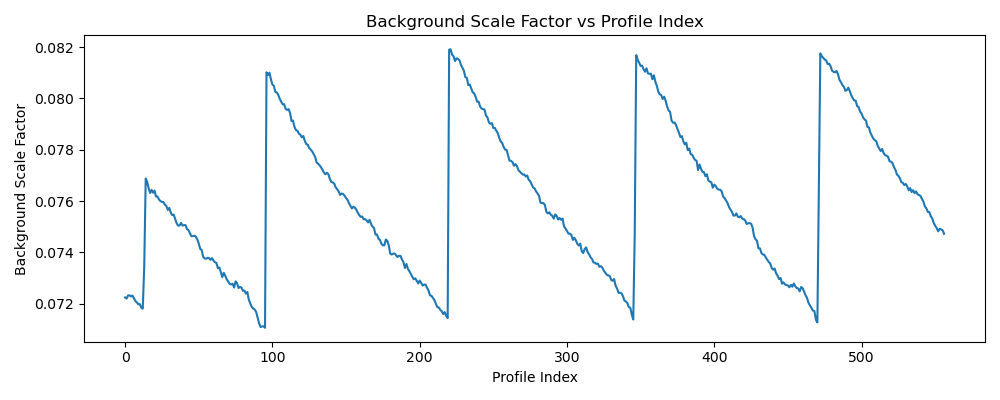

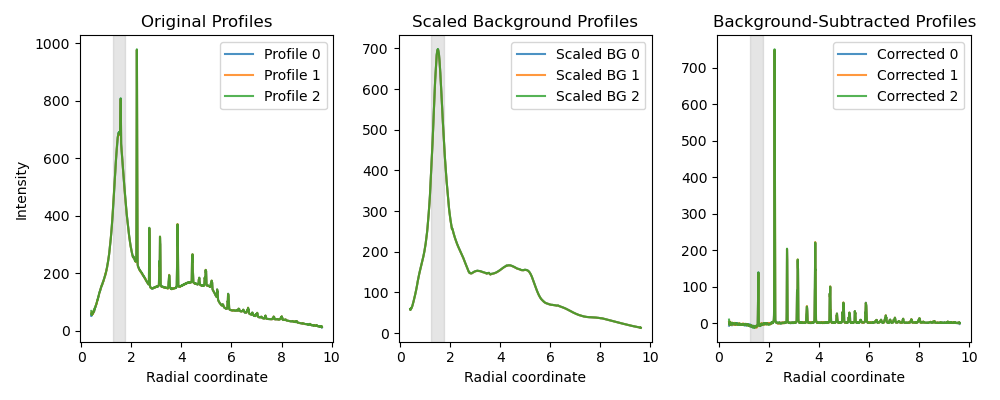

In [9]:
bgsub_result = trxrd.subtract_scaled_background_profile(
    radial=q,
    profiles=profiles,
    background_profile=background_profile,
    norm_range=(1.25, 1.75),   # example region; adjust as needed
    mode="mean",
    scale_method="ratio",
    plot=True,
    plot_scale_factors=True,
    plot_indices=[0, 1, 2],
    return_dict=True,
)

profiles_bgsub = bgsub_result["corrected_profiles"]
baselines = bgsub_result["scaled_background_profiles"]

# # Inspect Scaling Factors
# plt.figure(figsize=(8, 4))
# plt.plot(bgsub_result["scale_factors"])
# plt.xlabel("Image Index")
# plt.ylabel("Background Scale Factor")
# plt.title("Background Scale Factors")
# plt.show()

## Save Background

In [10]:
df = pd.DataFrame({
    "q": q_bg,
    "I(q)": baselines[0]/1000   # example: save the baseline for the first image
})

df.to_csv(
    f"{SAVE_PATH}/{COMPOSITION}_background.dat",
    sep=" ",
    index=False
)

## Check Drifts with SVD

dict_keys(['U', 'S', 'Vt', 'variance_explained', 'reconstruction', 'axis_values', 'time_values'])
Singular values (dI): [50568.14986915   666.85222585   316.54711541   175.34306331
   108.77277979]
Variance explained: [9.99565935e-01 1.73826717e-04 3.91682383e-05 1.20180636e-05
 4.62485130e-06]


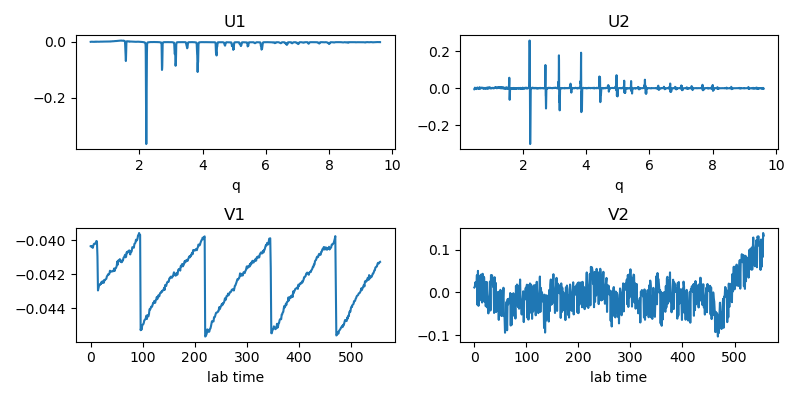

In [11]:
matrix = profiles_bgsub.T  # shape (n_q, n_delays)

svd_dict = trxrd.svd_analysis(
    data=matrix[20:, :], 
    axis_values=q[20:],
    time_values=delays
)
print(svd_dict.keys())

# Inspect
print("Singular values (dI):", svd_dict['S'][:5])
print("Variance explained:", svd_dict['variance_explained'][:5])

# Plot first two components

fig, axes = plt.subplots(2, 2, figsize=(8, 4))
for i in range(2):
    axes[0, i].plot(q[20:], svd_dict['U'][:, i])
    axes[0, i].set_xlabel('q'); axes[0, i].set_title(f'U{i+1}')
    axes[1, i].plot(svd_dict['Vt'][i, :])
    axes[1, i].set_xlabel('lab time'); axes[1, i].set_title(f'V{i+1}')
plt.tight_layout()

## Track and Correct Peak Drift

Detected 3 peak(s) at q = [2.21742825 2.71528031 3.84313033]


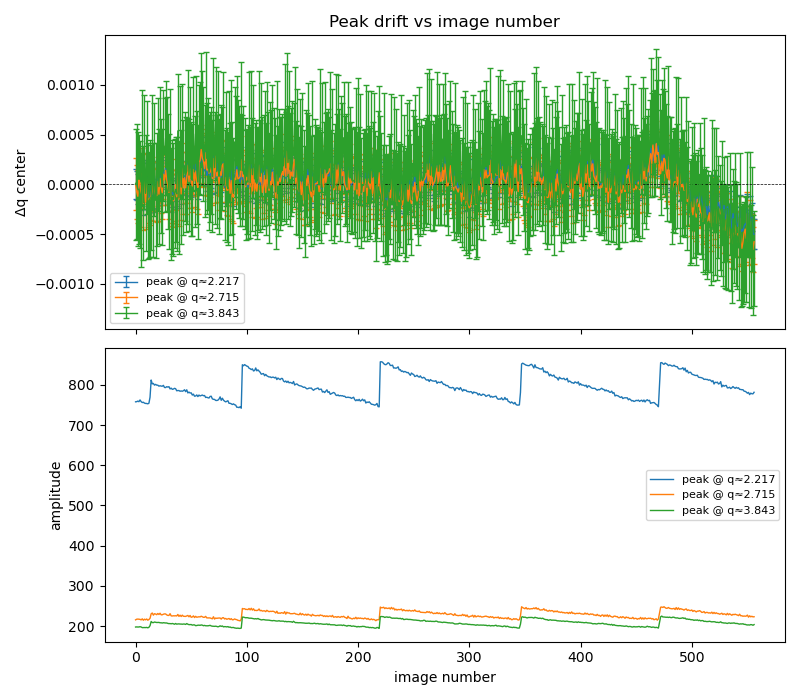

In [12]:
# q: (Nq,), I_stack: (Nq, Nimg)
results = trxrd.track_peaks(
    q, profiles_bgsub.T,
    ref="mean",          # average pattern is more robust than image 0
    prominence=200,      # <-- tune this; main knob for detection
    distance=1,          # min samples between peaks
)

fig, axes = trxrd.plot_drift(results, relative=True)
plt.show()

## Apply q Correction

In [13]:
s = trxrd.scale_drift_factor(results)
# Step 2: apply correction
q_corr, I_corr = trxrd.apply_scale_correction(q, profiles_bgsub.T, s, kind="cubic")

# Step 3: verify by re-running peak tracking on corrected data
results_corr, summary = trxrd.verify_correction(
    q_corr, I_corr, results,
    track_peaks_fn=trxrd.track_peaks,
    prominence=150,    # same as your original call
)

Trimmed 2 q points to avoid extrapolation.
Output q range: [0.4012, 9.6115]
Detected 5 peak(s) at q = [1.57206447 2.21742825 2.71528031 3.14552282 3.84313033]
    Peak q     Before (pp)      After (pp)   Reduction
-------------------------------------------------------
     2.217        4.12e-04        1.86e-05       95.5%
     2.715        3.92e-04        7.27e-05       81.4%
     3.843        4.26e-04        9.99e-05       76.5%


## Subtract Baseline from Images

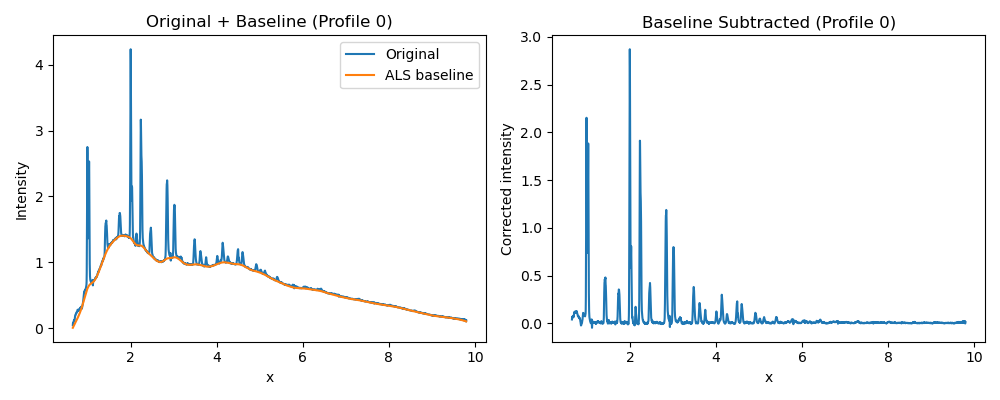

In [32]:
als_result = trxrd.subtract_als_baseline(
    data_array=profiles_norm,
    x_vals=q,
    lam=1e4,
    p=0.005,
    niter=10,
    plot=True,
    return_dict=True,
)

profiles_flat = als_result["corrected_data"]
baselines = als_result["baselines"]


## Make Reference Profile

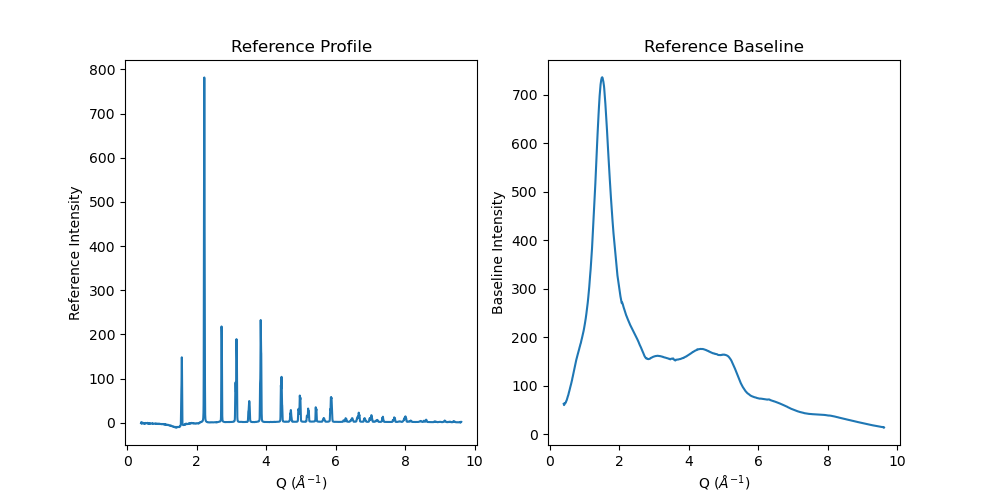

In [13]:
ref_result = trxrd.make_reference_profile(
    profiles=profiles_bgsub,
    delays=delays,
    reference_selector=None,
    return_dict=True,
)

ref_baseline = trxrd.make_reference_profile(
    profiles=baselines,
    delays=delays,
    reference_selector=None,
    return_dict=True,
)

reference_profile = ref_result["reference_profile"]
reference_baseline = ref_baseline["reference_profile"]

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(q, reference_profile)
plt.xlabel(r"Q ($\AA^{-1}$)")
plt.ylabel("Reference Intensity")
plt.title("Reference Profile")

plt.subplot(1, 2, 2)
plt.plot(q, reference_baseline)
plt.xlabel(r"Q ($\AA^{-1}$)")
plt.ylabel("Baseline Intensity")
plt.title("Reference Baseline")

plt.show()

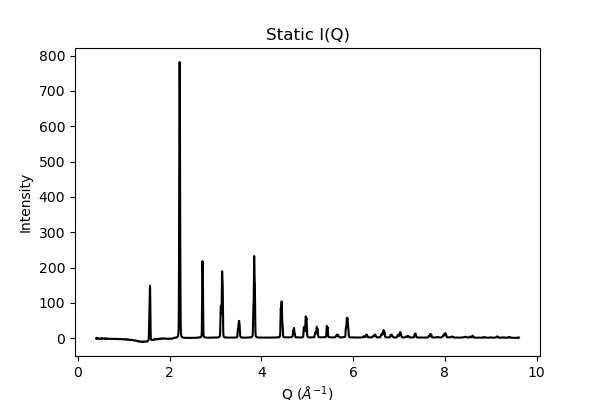

In [14]:
plt.figure(figsize=(6, 4))
plt.plot(q, reference_profile, color="k")
plt.xlabel(r"Q ($\AA^{-1}$)")
plt.ylabel("Intensity")
plt.title("Static I(Q)")
plt.show()

## Compute Difference Profiles

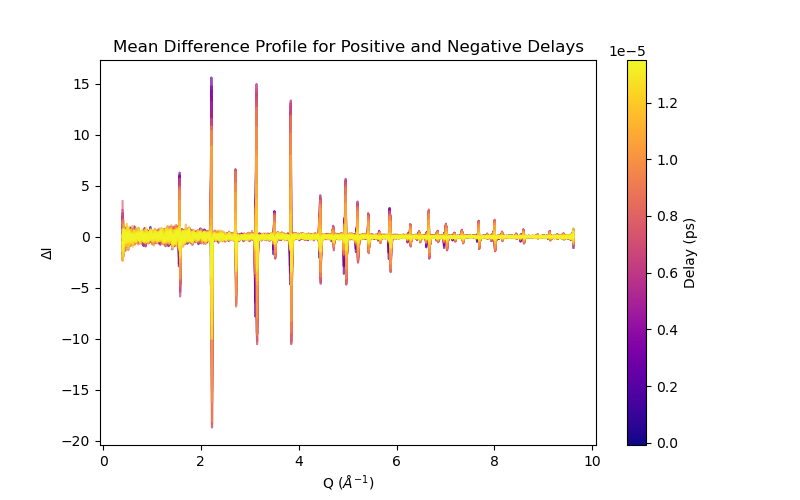

In [21]:
delta_result = trxrd.compute_delta_profiles(
    profiles=profiles_bgsub,
    reference_profile=reference_profile,
    mode="subtract",
    return_dict=True,
)

baseline_results = trxrd.compute_delta_profiles(
    profiles=baselines,
    reference_profile=reference_baseline,
    mode="subtract",
    return_dict=True,
)

delta_profiles = delta_result["delta_profiles"]
delta_baselines = baseline_results["delta_profiles"]


unique_delays_plot = np.unique(delays)
colors = plt.cm.plasma(np.linspace(0, 1, len(unique_delays_plot)))

fig, ax = plt.subplots(figsize=(8, 5))
for color, delay in zip(colors, unique_delays_plot):
    mean_profile = np.mean(delta_profiles[np.where(delays == delay)[0]], axis=0)
    ax.plot(q, mean_profile, alpha=0.7, label=f"Delay {delay} ps", color=color)
ax.set_xlabel(r"Q ($\AA^{-1}$)")
ax.set_ylabel("ΔI")
ax.set_title("Mean Difference Profile for Positive and Negative Delays")
# ax.legend(loc=(.7, 0))

import matplotlib.cm as cm
import matplotlib.colors as mcolors
norm = mcolors.Normalize(vmin=unique_delays_plot.min(), vmax=unique_delays_plot.max())
sm = cm.ScalarMappable(cmap="plasma", norm=norm)
sm.set_array([])
fig.colorbar(sm, ax=ax, label="Delay (ps)")

plt.show()

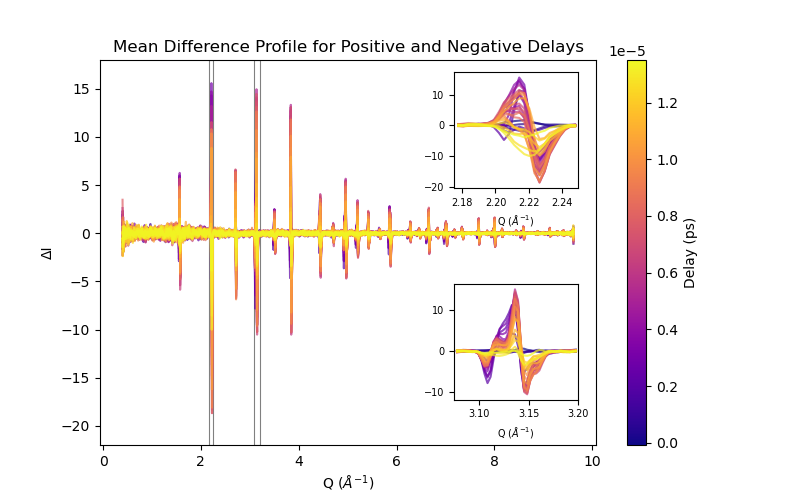

In [35]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.patches import Rectangle

fig, ax = plt.subplots(figsize=(8, 5))
for color, delay in zip(colors, unique_delays_plot):
    mean_profile = np.mean(delta_profiles[np.where(delays == delay)[0]], axis=0)
    ax.plot(q, mean_profile, alpha=0.7, color=color)
ax.set_xlabel(r"Q ($\AA^{-1}$)")
ax.set_ylabel("ΔI")
ax.set_title("Mean Difference Profile for Positive and Negative Delays")
ax.set_ylim(-22, 18)

norm = mcolors.Normalize(vmin=unique_delays_plot.min(), vmax=unique_delays_plot.max())
sm = cm.ScalarMappable(cmap="plasma", norm=norm)
sm.set_array([])
fig.colorbar(sm, ax=ax, label="Delay (ps)")

# (q_lo, q_hi, bbox_to_anchor) — all in axes-fraction coords (0–1)
inset_configs = [
    (2.175, 2.25,  (0.7, 0.65, 1, 1)),   # upper right
    (3.075, 3.20,  (0.7, 0.1, 1, 1)),   # lower right, shifted up to stay inside axes
]

for q_lo, q_hi, anchor in inset_configs:
    axins = inset_axes(ax, width="25%", height="30%",
                       loc="lower left",
                       bbox_to_anchor=anchor,
                       bbox_transform=ax.transAxes)
    mask = (q >= q_lo) & (q <= q_hi)
    for color, delay in zip(colors, unique_delays_plot):
        mean_profile = np.mean(delta_profiles[np.where(delays == delay)[0]], axis=0)
        axins.plot(q[mask], mean_profile[mask], alpha=0.7, color=color)
    axins.set_xlim(q_lo, q_hi)
    axins.tick_params(labelsize=7)
    axins.set_xlabel(r"Q ($\AA^{-1}$)", fontsize=7)
    # ax.indicate_inset_zoom(axins, edgecolor="gray")
    ax.add_patch(Rectangle((q_lo, ax.get_ylim()[0]), q_hi - q_lo,
                        ax.get_ylim()[1] - ax.get_ylim()[0],
                        fill=False, edgecolor="gray", linewidth=0.8))

plt.show()

## Average by Delay

Delay -8e-08: 17 profiles averaged
Delay -1e-08: 18 profiles averaged
Delay -5e-09: 18 profiles averaged
Delay 2e-10: 17 profiles averaged
Delay 4e-10: 17 profiles averaged
Delay 6e-10: 17 profiles averaged
Delay 8e-10: 18 profiles averaged
Delay 1e-09: 18 profiles averaged
Delay 2e-09: 18 profiles averaged
Delay 3.5e-09: 18 profiles averaged
Delay 5e-09: 17 profiles averaged
Delay 1e-08: 18 profiles averaged
Delay 2e-08: 18 profiles averaged
Delay 3e-08: 18 profiles averaged
Delay 4e-08: 17 profiles averaged
Delay 5e-08: 17 profiles averaged
Delay 6e-08: 18 profiles averaged
Delay 8e-08: 17 profiles averaged
Delay 1e-07: 18 profiles averaged
Delay 1.5e-07: 17 profiles averaged
Delay 2.5e-07: 17 profiles averaged
Delay 3.75e-07: 18 profiles averaged
Delay 5e-07: 17 profiles averaged
Delay 7.5e-07: 17 profiles averaged
Delay 1e-06: 17 profiles averaged
Delay 1.626e-06: 17 profiles averaged
Delay 2.688e-06: 17 profiles averaged
Delay 3.75e-06: 17 profiles averaged
Delay 5e-06: 18 profile

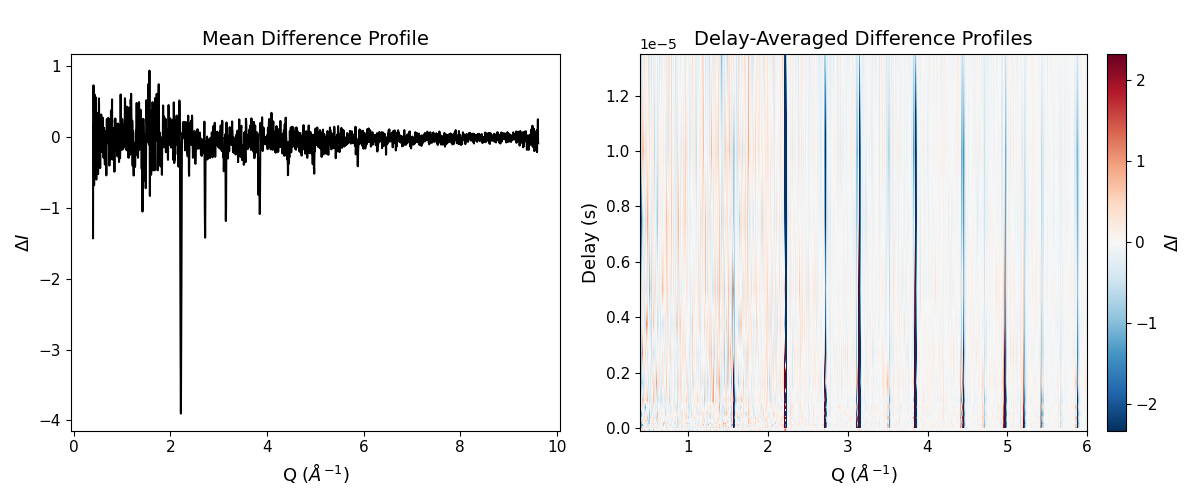

In [47]:
from scipy.interpolate import RegularGridInterpolator

delay_result = trxrd.average_profiles_by_delay(
    profiles=delta_profiles,
    delays=delays,
    unique_delays=None,
    return_dict=True,
)

unique_delays = delay_result["unique_delays"]
mean_profiles = delay_result["mean_profiles"]

CLIP_PCT   = 97.5
Q_MAX_PLOT = 6.0
N_Q_FINE   = 800
N_D_FINE   = 300
FONT_LBL   = 13
FONT_TCK   = 11
FONT_TTL   = 14

# Interpolate heatmap onto fine uniform grid
_qmask    = q <= Q_MAX_PLOT
q_plot    = q[_qmask]
data_plot = mean_profiles[:, _qmask]

interp_fn = RegularGridInterpolator(
    (unique_delays, q_plot), data_plot,
    method="linear", bounds_error=False, fill_value=np.nan,
)
q_fine    = np.linspace(q_plot.min(), q_plot.max(), N_Q_FINE)
d_fine    = np.linspace(unique_delays.min(), unique_delays.max(), N_D_FINE)
qq, dd    = np.meshgrid(q_fine, d_fine)
data_fine = interp_fn((dd, qq))

clim_val = np.nanpercentile(np.abs(data_plot), CLIP_PCT)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(q, mean_profiles[-1], color="k")
axes[0].set_xlabel(r"Q ($\AA^{-1}$)", fontsize=FONT_LBL)
axes[0].set_ylabel(r"$\Delta I$", fontsize=FONT_LBL)
axes[0].set_title("Mean Difference Profile", fontsize=FONT_TTL)
axes[0].tick_params(labelsize=FONT_TCK)

pcm = axes[1].pcolormesh(q_fine, d_fine, data_fine,
                          shading="auto", cmap="RdBu_r",
                          vmin=-clim_val, vmax=clim_val)
cb = fig.colorbar(pcm, ax=axes[1], fraction=0.046, pad=0.04)
cb.set_label(r"$\Delta I$", fontsize=FONT_LBL)
cb.ax.tick_params(labelsize=FONT_TCK)

axes[1].set_xlabel(r"Q ($\AA^{-1}$)", fontsize=FONT_LBL)
axes[1].set_ylabel("Delay (s)", fontsize=FONT_LBL)
axes[1].set_title("Delay-Averaged Difference Profiles", fontsize=FONT_TTL)
axes[1].tick_params(labelsize=FONT_TCK)

plt.tight_layout()
plt.show()

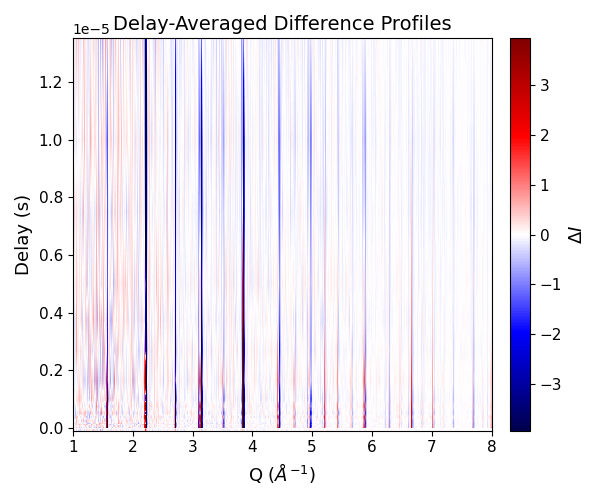

In [53]:
from scipy.interpolate import RegularGridInterpolator

CLIP_PCT   = 99      # percentile for symmetric color clipping; lower → more saturated
Q_MIN_PLOT = 1.0     # Å⁻¹ — trim low-Q where signal is often dominated by artifacts
Q_MAX_PLOT = 8.0     # Å⁻¹ — trim high-Q where signal is sparse
N_Q_FINE   = 800     # interpolated grid resolution along Q
N_D_FINE   = 300     # interpolated grid resolution along delay
FONT_LBL   = 13
FONT_TCK   = 11
FONT_TTL   = 14

# Trim to Q_MIN_PLOT and Q_MAX_PLOT then interpolate onto a fine uniform grid
_qmask   = (q >= Q_MIN_PLOT) & (q <= Q_MAX_PLOT)
q_plot   = q[_qmask]
data_plot = mean_profiles[:, _qmask]

interp_fn = RegularGridInterpolator(
    (unique_delays, q_plot), data_plot,
    method="linear", bounds_error=False, fill_value=np.nan,
)
q_fine    = np.linspace(q_plot.min(), q_plot.max(), N_Q_FINE)
d_fine    = np.linspace(unique_delays.min(), unique_delays.max(), N_D_FINE)
qq, dd    = np.meshgrid(q_fine, d_fine)
data_fine = interp_fn((dd, qq))

clim_val = np.nanpercentile(np.abs(data_plot), CLIP_PCT)

fig, ax = plt.subplots(figsize=(6, 5))
pcm = ax.pcolormesh(q_fine, d_fine, data_fine,
                    shading="auto", cmap="seismic",
                    vmin=-clim_val, vmax=clim_val)

cb = fig.colorbar(pcm, ax=ax, fraction=0.046, pad=0.04)
cb.set_label(r"$\Delta I$", fontsize=FONT_LBL)
cb.ax.tick_params(labelsize=FONT_TCK)

ax.set_xlabel(r"Q ($\AA^{-1}$)", fontsize=FONT_LBL)
ax.set_ylabel("Delay (s)", fontsize=FONT_LBL)
ax.set_title("Delay-Averaged Difference Profiles", fontsize=FONT_TTL)
ax.tick_params(labelsize=FONT_TCK)

plt.tight_layout()
# fig.savefig(SAVE_PATH / "delay_averaged_difference_profiles.png", dpi=300, bbox_inches="tight")
plt.show()

## Perform SVD

Singular values (dI): [225.27986423  69.66380766  39.54425599  12.63045735  10.83422502]
Variance explained: [0.86171467 0.08240113 0.02655129 0.00270867 0.00199303]


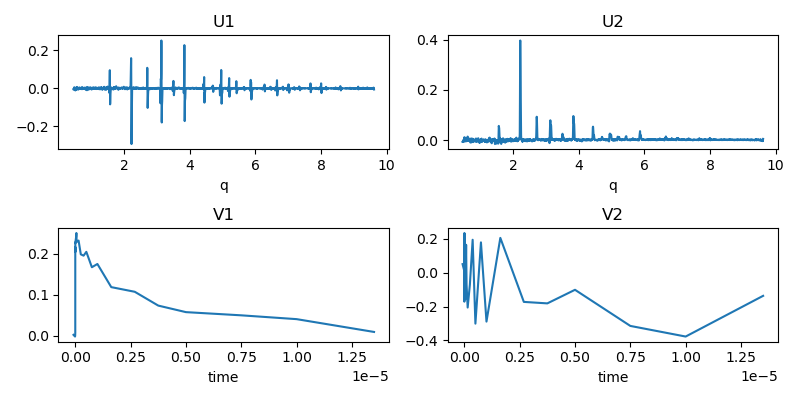

In [54]:
matrix = mean_profiles.T  # shape (n_q, n_delays)

svd_dict = trxrd.svd_analysis(
    data=matrix[20:, :], 
    axis_values=q[20:],
    time_values=unique_delays
)
svd_dict.keys()

# Inspect
print("Singular values (dI):", svd_dict['S'][:5])
print("Variance explained:", svd_dict['variance_explained'][:5])

# Plot first two components

fig, axes = plt.subplots(2, 2, figsize=(8, 4))
for i in range(2):
    axes[0, i].plot(q[20:], svd_dict['U'][:, i])
    axes[0, i].set_xlabel('q'); axes[0, i].set_title(f'U{i+1}')
    axes[1, i].plot(unique_delays, svd_dict['Vt'][i, :])
    axes[1, i].set_xlabel('time'); axes[1, i].set_title(f'V{i+1}')
plt.tight_layout()

## Plot Lineouts 

In [59]:
q_ranges = [(2.20, 2.22), (2.22, 2.24), (2.70, 2.7125), (2.712, 2.7135)]

lineout_result = trxrd.lineouts_by_delay_from_per_image_profiles(
    radial=q,
    delta_profiles=delta_profiles,
    delays=delays,
    q_ranges=q_ranges,
    average_mode="mean",
    error_type="sem",
    plot=False,
    return_dict=True,
)

unique_delays   = lineout_result["unique_delays"]
mean_lineouts   = lineout_result["mean_lineouts"]
errors          = lineout_result["sem_lineouts"]   # swap to std_lineouts if preferred

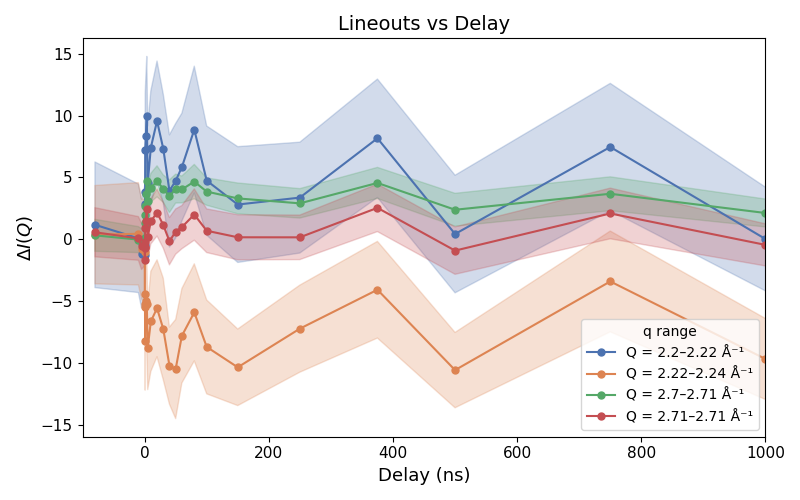

In [74]:
# ── Tunable plot parameters ──────────────────────────────────────────────────
FIGSIZE       = (8, 5)
MARKER        = "o"
MARKERSIZE    = 5
LINESTYLE     = "-"
LINEWIDTH     = 1.5
ALPHA_FILL    = 0.25          # shaded error band opacity
DELAY_SCALE   = 1e9           # 1 → s, 1e3 → ms, 1e9 → ns, 1e12 → ps
DELAY_UNIT    = "ns"          # label for x-axis
LOG_X         = False         # True for log-delay axis
XLIM          = -100, 1000          # e.g. (-1, 10) or None for auto
YLIM          = None          # e.g. (-5, 5) or None for auto
XLABEL        = f"Delay ({DELAY_UNIT})"
YLABEL        = r"$\Delta I(Q)$"
TITLE         = "Lineouts vs Delay"
LEGEND_LOC    = "best"
CMAP          = None      # any matplotlib colormap name, or None for default cycle
COLORS        = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]         # explicit list of colors — overrides CMAP if set
# ─────────────────────────────────────────────────────────────────────────────

x = unique_delays * DELAY_SCALE
n = len(q_ranges)

if COLORS is not None:
    color_list = COLORS
elif CMAP is not None:
    color_list = plt.get_cmap(CMAP)(np.linspace(0, 1, n))
else:
    color_list = [None] * n

fig, ax = plt.subplots(figsize=FIGSIZE)

for i, q_range in enumerate(q_ranges):
    qmin, qmax = q_range
    label = f"Q = {qmin:.3g}–{qmax:.3g} Å⁻¹"

    line, = ax.plot(
        x, mean_lineouts[i],
        marker=MARKER, markersize=MARKERSIZE,
        linestyle=LINESTYLE, linewidth=LINEWIDTH,
        label=label, color=color_list[i],
    )
    ax.fill_between(
        x,
        mean_lineouts[i] - errors[i],
        mean_lineouts[i] + errors[i],
        alpha=ALPHA_FILL,
        color=line.get_color(),
    )

if LOG_X:
    ax.set_xscale("log")
if XLIM is not None:
    ax.set_xlim(XLIM)
if YLIM is not None:
    ax.set_ylim(YLIM)

ax.set_xlabel(XLABEL, fontsize=13)
ax.set_ylabel(YLABEL, fontsize=13)
ax.set_title(TITLE, fontsize=14)
ax.legend(title="q range", loc=LEGEND_LOC)
ax.tick_params(labelsize=11)
plt.tight_layout()
plt.show()

## Check Baseline per Delay

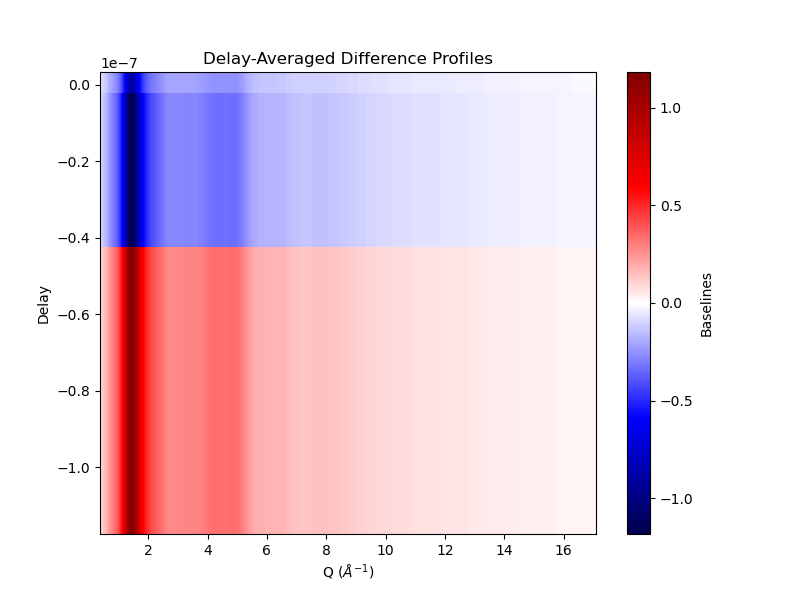

In [ ]:
delay_result = trxrd.average_profiles_by_delay(
    profiles=delta_baselines,
    delays=delays,
    unique_delays=None,
    return_dict=True,
)

unique_delays = delay_result["unique_delays"]
mean_bkgs = delay_result["mean_profiles"]
std_bkgs = delay_result["std_profiles"]

# Plot Heatmap of mean profiles vs delay
plt.figure(figsize=(8, 6))
plt.pcolormesh(q, unique_delays, mean_bkgs, shading="auto", cmap="seismic")
plt.colorbar(label="Baselines")
#plt.clim(-0.02, 0.02)  # set color limits for better contrast; adjust as needed
plt.xlabel(r"Q ($\AA^{-1}$)")
plt.ylabel("Delay")
plt.title("Delay-Averaged Difference Profiles")
plt.show()

## Calculate f and f(2)

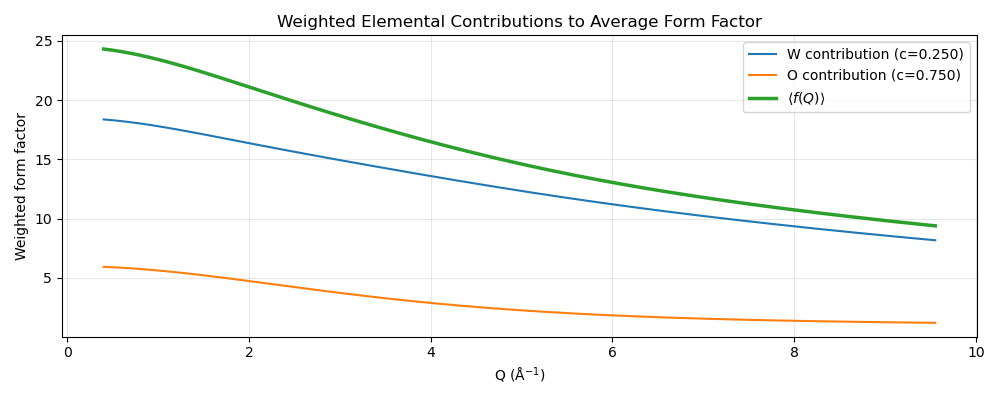

In [24]:
ff_results = trxrd.compute_average_form_factors(q, COMPOSITION, plot=True)

f_avg = ff_results["f_avg"]
f2_avg = ff_results["f2_avg"]


## Apply I(Q) High Q Correction Based on Form Factors

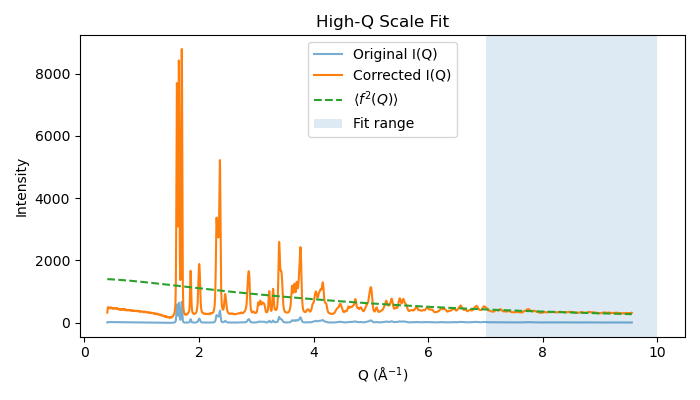

In [26]:
corr = trxrd.correct_iq(
    q=q,
    iq=profiles_bgsub,
    composition=COMPOSITION,
    q_fit_range=(7,10),
    background="constant",
    plot=True,
    return_dict=True,
)

iq_corrected = corr["iq_corrected"]

## Calculate S(Q) and F(Q)

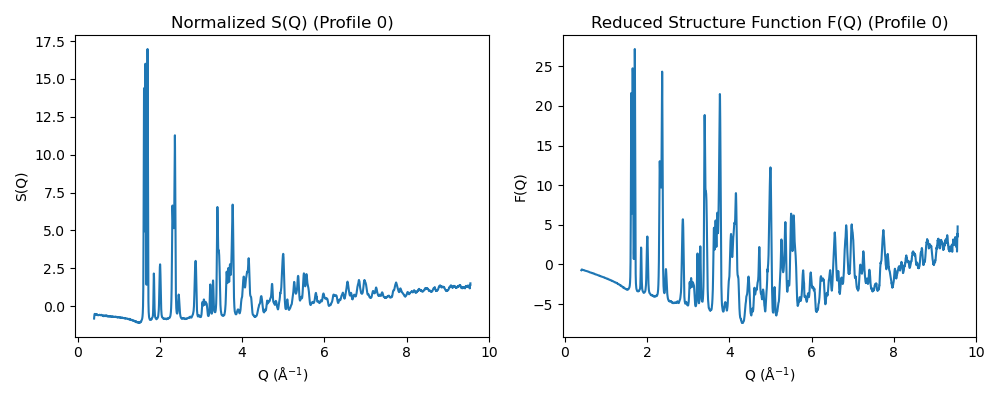

In [27]:
sq_result = trxrd.normalize_xray_scattering_to_sq_fq(
    q=q,
    iq=iq_corrected,
    composition=COMPOSITION,
    mode="total",
    plot=True,
    return_dict=True,
)

sq = sq_result["sq"]
fq = sq_result["fq"]


## Optional Polynomial Correction

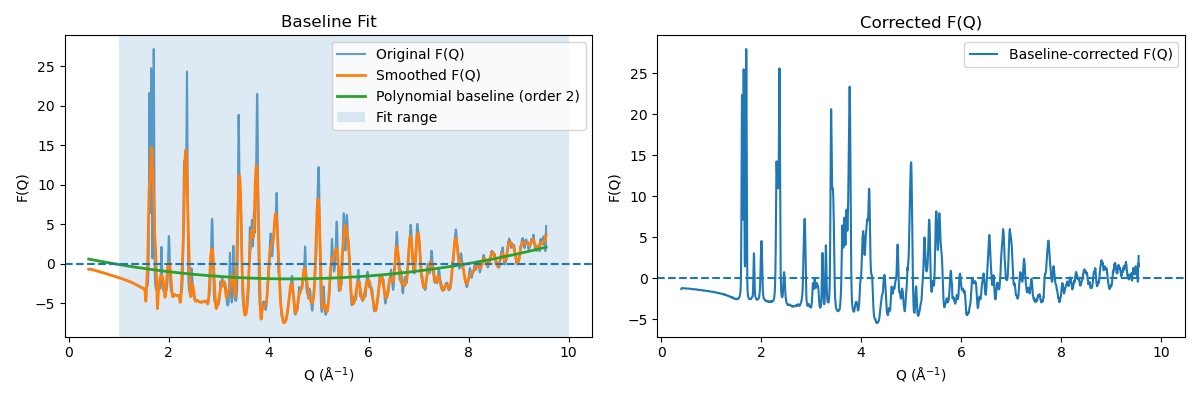

In [31]:
fq_corr_result = trxrd.apply_polynomial_baseline(
    q=q,
    fq=fq,
    q_fit_range=(1.0, 10.0),   # or maybe (10.0, 17.0)
    poly_order=2,
    smooth_window=51,
    smooth_polyorder=3,
    plot=True,
    return_dict=True,
)

fq_corrected = fq_corr_result["fq_corrected"]

## Calculate G(r)

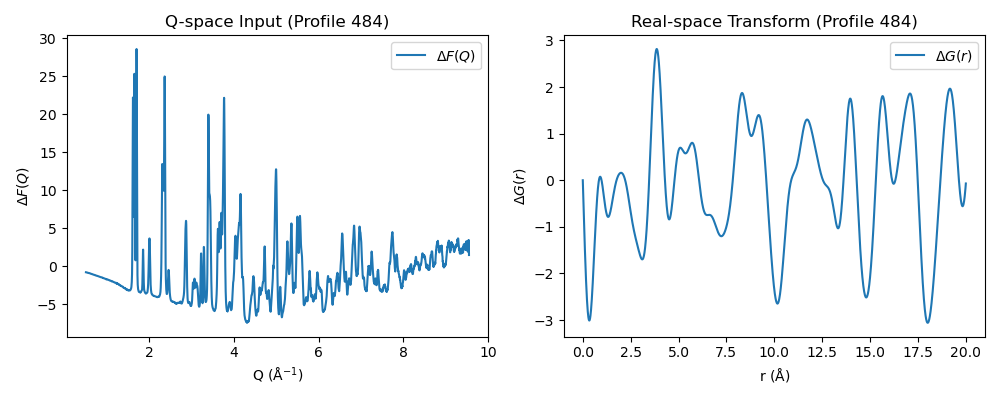

(485, 2000)


In [ ]:
Gr_result = trxrd.compute_delta_gr_from_delta_fq(
    q=q,
    delta_fq=fq,
    r_max=R_MAX,
    n_r=N_R,
    q_range=(Q_MIN, Q_MAX),
    window=WINDOW,
    plot=True,
    profile_index=len(fq)-1,  # example: use last profile (e.g. longest delay)
    return_dict=True,
)

r = Gr_result["r"]
Gr_profiles = Gr_result["delta_gr"]
print(Gr_profiles.shape)   # should be (n_profiles, n_r)


Gr_delay_result = trxrd.average_profiles_by_delay(
    profiles=Gr_profiles,
    delays=delays,
    unique_delays=None,
    return_dict=True,
)

unique_delays = Gr_delay_result["unique_delays"]
mean_Gr = Gr_delay_result["mean_profiles"]
r = Gr_result["r"]

## Calculate dS(Q) and dF(Q)

c:\Users\lheald\Documents\Guzelturk_Lab\trxrd\trxrd.py:4564: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, axes = plt.subplots(1, 2, figsize=figsize, sharex=True)


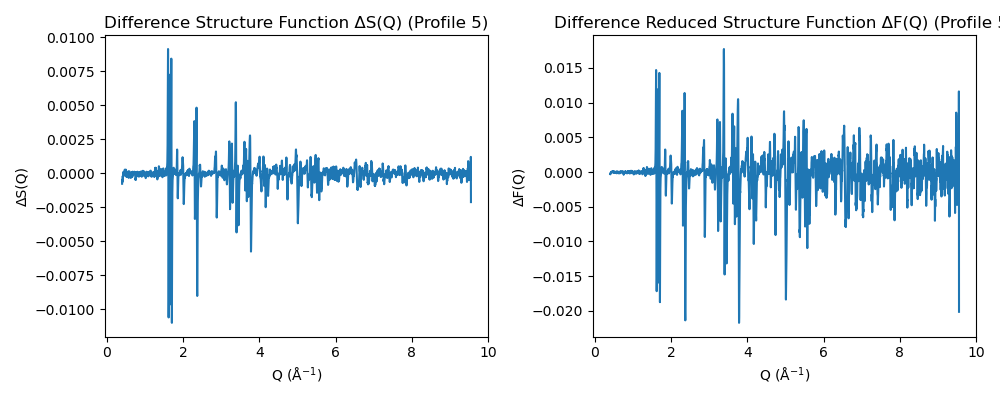

In [15]:
delta_result = trxrd.normalize_xray_scattering_to_sq_fq(
    q=q,
    iq=mean_profiles,  # example: use mean profiles for normalization
    composition=COMPOSITION,
    mode="difference",
    plot=True,
    profile_index=len(mean_profiles)-1,  # example: use last profile (e.g. longest delay)
    return_dict=True,
)


delta_sq = delta_result["delta_sq"]
delta_fq = delta_result["delta_fq"]

## Calculate dG(r)

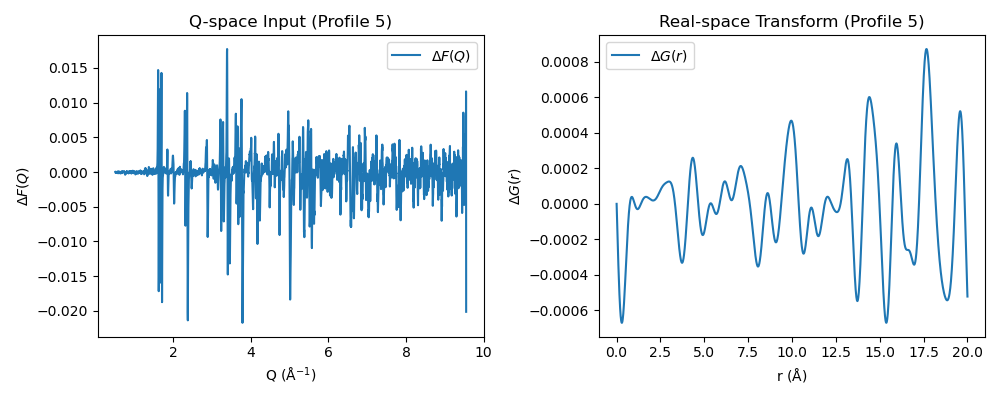

(6, 2000)


In [16]:
dGr_result = trxrd.compute_delta_gr_from_delta_fq(
    q=q,
    delta_fq=delta_fq,
    r_max=R_MAX,
    n_r=N_R,
    q_range=(Q_MIN, Q_MAX),
    window=WINDOW,
    plot=True,
    profile_index=len(delta_fq)-1,  # example: use last profile (e.g. longest delay)
    return_dict=True,
)

r = dGr_result["r"]
dGr_profiles = dGr_result["delta_gr"]
print(dGr_profiles.shape)   # should be (n_profiles, n_r)

## Plot Delay Averaged dG(r)

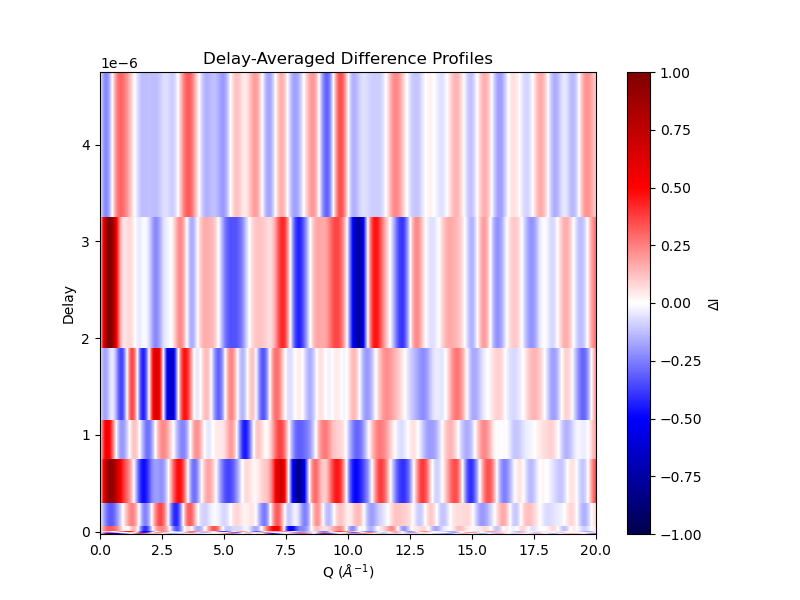

In [23]:
# Plot Heatmap of mean profiles vs delay
plt.figure(figsize=(8, 6))
plt.pcolormesh(r, unique_delays, dGr_profiles/np.nanmax(dGr_profiles), shading="auto", cmap="seismic")
plt.colorbar(label="ΔI")
plt.clim(-1, 1)  # set color limits for better contrast; adjust as needed
plt.xlabel(r"Q ($\AA^{-1}$)")
plt.ylabel("Delay")
plt.title("Delay-Averaged Difference Profiles")
plt.show()

## Compare Results

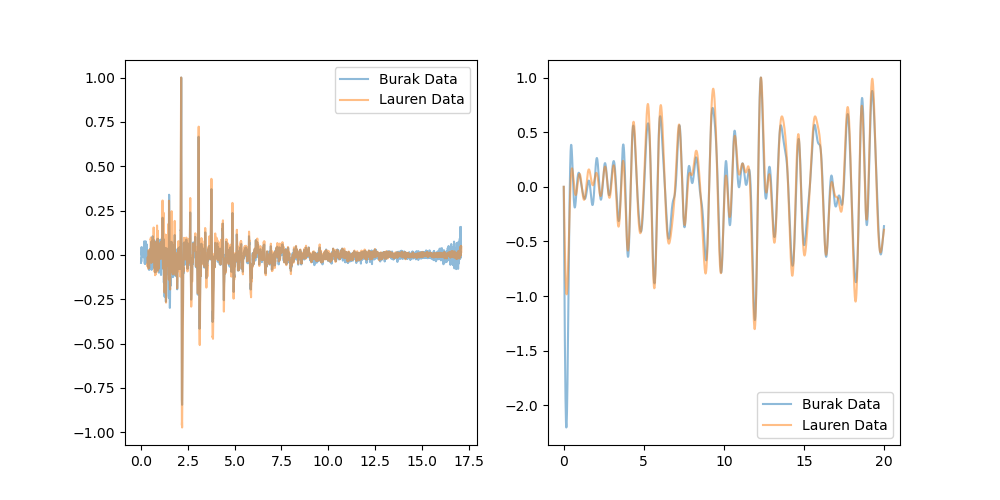

In [35]:
df = pd.read_excel("C:\\Users\\lheald\\Documents\\Guzelturk_Lab\\TRXRDPython\\testdata\\output\\BaTiO3_data_CottsExp_Nov25.xlsx", header=2)

plt.figure(figsize=(10, 5))
plt.subplot(1,2,1)
plt.plot(df["Q"], df["deltaI(Q,0.6ns)"]/np.nanmax(df["deltaI(Q,0.6ns)"]), alpha=0.5, label="Burak Data")
plt.plot(q, mean_profiles[-1]/np.nanmax(mean_profiles[-1]), alpha=0.5, label="Lauren Data")
#plt.xlim(0,10)
plt.legend()

plt.subplot(1,2,2)
plt.plot(df["r"], df["deltaG(r,0.6ns)"]/np.nanmax(df["deltaG(r,0.6ns)"]), alpha=0.5, label="Burak Data")
plt.plot(r, dGr_profiles[-1]/np.nanmax(dGr_profiles[-1]), alpha=0.5, label="Lauren Data")
plt.legend()
plt.show()


In [23]:
# to_csv = {"q": q,
#           "deltaI_0.6ns": mean_profiles[2],
#           "deltaI_-5ns": mean_profiles[1],
#           }

# pd.DataFrame(to_csv).to_csv("BaTiO3_deltaI_profiles.csv", index=False)

to_csv = {"r": r, 
          "dGr_0": dGr_profiles[0],
          "dGr_1": dGr_profiles[1],
          "dGr_2": dGr_profiles[2],
          "dGr_3": dGr_profiles[3],
          "dGr_4": dGr_profiles[4],
          "dGr_5": dGr_profiles[5],
          }

pd.DataFrame(to_csv).to_csv("WO3_deltaGr_profile.csv", index=False)

In [21]:
unique_delays

array([-8.e-08, -1.e-08,  1.e-10,  2.e-10,  1.e-09,  1.e-07])

## Load PDF from Crystal Maker/PDFgetX3

Try smoothing with moving average or lowess filter etc to make more like experimental data

In [24]:
r_vals_cm, pdf_vals_cm = np.loadtxt("C:\\Users\\lheald\\Downloads\\BaTiO3 graph data.txt", skiprows=3, unpack=True)
dr = r_vals_cm[1] - r_vals_cm[0]
pdf_smooth_cm = gaussian_filter1d(pdf_vals_cm, sigma=2)

r_pdfget, pdf_pdfget = np.loadtxt("C:\\Users\\lheald\\Documents\\Guzelturk_Lab\\Cotts_Processed_Data\\BTO400nmS3_240Ksurv3_10uJ_-0fs_00000.gr", skiprows=26, unpack=True)


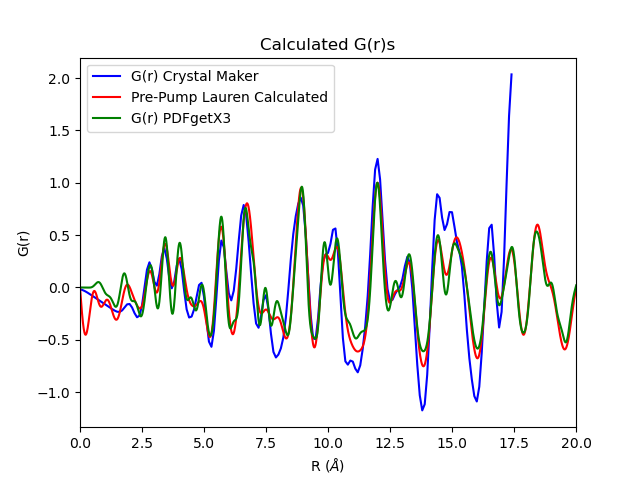

In [33]:
plt.figure()
#plt.plot(r_vals, pdf_vals)
plt.plot(r_vals_cm, pdf_smooth_cm/25, label="G(r) Crystal Maker", color="blue")
plt.plot(r, mean_Gr[0]/np.nanmax(mean_Gr[0]), label="Pre-Pump Lauren Calculated", color="red")
plt.plot(r_pdfget, pdf_pdfget/np.nanmax(pdf_pdfget), label="G(r) PDFgetX3", color="green")
# plt.plot(r, (dGr_profiles[-1]*5/np.nanmax(dGr_profiles[-1])) - 10, label="dG(r)", color="red")
# plt.plot(r, mean_Gr[-1], label="post-pump")
plt.xlabel(r"R ($\AA$)")
plt.ylabel("G(r)")
plt.title("Calculated G(r)s")
plt.legend()
plt.xlim(0, 20)
#plt.ylim(-3, 3)
plt.show()

## Save Results

In [ ]:
# np.savez(
#     "trxrd_processed_results.npz",
#     q=q,
#     delays=clean_dict["delay"],
#     image_numbers=clean_dict["image_number"],
#     centers=centers,
#     profiles=profiles,
#     profiles_bgsub=profiles_bgsub,
#     profiles_norm=profiles_norm,
#     reference_profile=reference_profile,
#     delta_profiles=delta_profiles,
#     unique_delays=unique_delays,
#     mean_profiles=mean_profiles,
#     std_profiles=std_profiles,
# )

: 